In [3]:
import pandas as pd
import numpy as np

In [4]:
telemetry = pd.read_csv('/content/PdM_telemetry.csv', parse_dates=['datetime'], on_bad_lines='skip')
failures  = pd.read_csv('/content/PdM_failures.csv', parse_dates=['datetime'])
maint     = pd.read_csv('/content/PdM_maint.csv', parse_dates=['datetime'])
machines  = pd.read_csv('/content/PdM_machines.csv')
errors    = pd.read_csv('/content/PdM_errors.csv', parse_dates=['datetime'])

print(telemetry.shape, failures.shape, maint.shape, machines.shape, errors.shape)
telemetry.head()

(23159, 6) (761, 3) (3286, 3) (100, 3) (3919, 3)


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


###  Build the RUL label

In [5]:
# Step 1: Combine failure and maintenance events into one list of "reset" moments
resets = pd.concat([
    failures[['datetime', 'machineID']],
    maint[['datetime', 'machineID']]
]).drop_duplicates()

# Step 2: Both tables MUST be sorted by datetime for merge_asof to work
telemetry_sorted = telemetry.sort_values('datetime')
resets_sorted = resets.sort_values('datetime').rename(columns={'datetime': 'reset_time'})

# Step 3: For every sensor reading, find the NEXT reset time that comes after it
df = pd.merge_asof(
    telemetry_sorted,
    resets_sorted,
    left_on='datetime',
    right_on='reset_time',
    by='machineID',           # only match resets from the SAME machine
    direction='forward',      # look forward in time, not backward
    allow_exact_matches=False # don't match a reset happening at the exact same instant
)

# Step 4: RUL = hours between the sensor reading and that next reset
df['RUL'] = (df['reset_time'] - df['datetime']) / pd.Timedelta(hours=1)

# Drop rows where no future reset was found (end of a machine's recorded life)
df = df.dropna(subset=['RUL'])

In [6]:
df = df.sort_values(['machineID', 'datetime'])

window = 24  # 24-hour rolling window
sensor_cols = ['volt', 'rotate', 'pressure', 'vibration']

for col in sensor_cols:
    df[f'{col}_roll_mean'] = df.groupby('machineID')[col].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    df[f'{col}_roll_std'] = df.groupby('machineID')[col].transform(
        lambda x: x.rolling(window, min_periods=1).std())

df[[c for c in df.columns if 'roll' in c]] = df[[c for c in df.columns if 'roll' in c]].fillna(0)

### Add error counts

In [7]:
errors_24h = errors.copy()
errors_24h['datetime'] = errors_24h['datetime'].dt.floor('h')

error_counts = errors_24h.groupby(['machineID', 'datetime']).size().reset_index(name='error_count')

df = df.merge(error_counts, on=['machineID', 'datetime'], how='left')
df['error_count'] = df['error_count'].fillna(0)

In [8]:
#merge machine metadata
df = df.merge(machines, on='machineID', how='left')
df = pd.get_dummies(df, columns=['model'], drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_cols = [c for c in df.columns if c not in ['datetime', 'machineID', 'RUL', 'reset_time']]
X = df[feature_cols]
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [10]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.2f} hours")
print(f"RMSE: {rmse:.2f} hours")
print(f"R²: {r2:.3f}")

MAE: 86.50 hours
RMSE: 121.89 hours
R²: 0.362


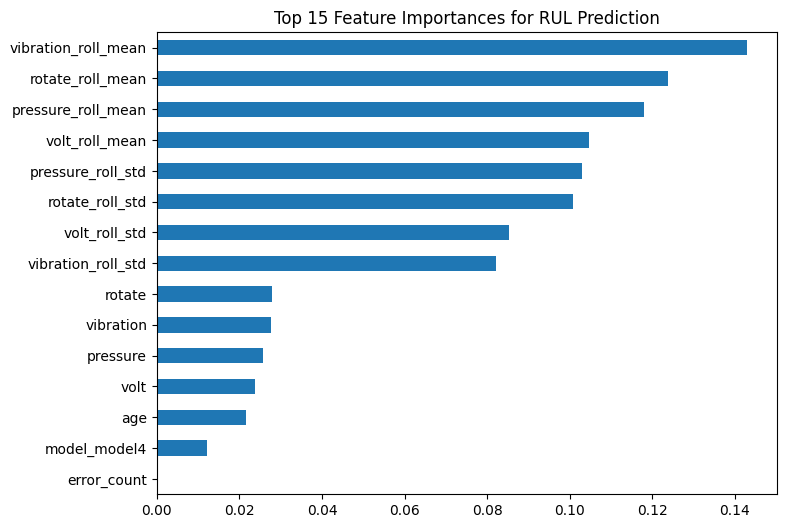

In [11]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 Feature Importances for RUL Prediction')
plt.gca().invert_yaxis()
plt.show()

In [12]:
from sklearn.metrics import accuracy_score

# y_true = actual/ground truth labels
# y_pred = predicted labels from your model
y_true = [0, 1, 1, 0, 1, 0, 1, 1]
y_pred = [0, 1, 0, 0, 1, 1, 1, 1]

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 75.00%


In [13]:
import joblib
joblib.dump(model, 'IOT Failure System.joblib')

['IOT Failure System.joblib']